# Advanced clustering on real-world data

For this practical, you will work in groups (between 2 and 4). You will apply the questions in this notebook to your assigned dataset. (Note that some of the datasets are very large (>10k samples). This might make the execution of some algorithms very slow. If that is the case, do not hesitate to talk to your teacher.)

**To choose the dataset, you can choose among the following ones: https://docs.google.com/spreadsheets/d/1TAJ_lEyOs6UnGoT13BLYU7jzVS2ts3wgomZ5GmjdnNo/edit?usp=sharing.**

**Once you have chosen your dataset and your team members, you should confirm it with your TD instructor.**

Then, you can register in eCampus with the corresponding group.

**You should upload this notebook filled in eCampus before Sunday 2 November at 11.59pm.**

If the submission in eCampus is not working, you can send it to either **massinissa.hamidi@univ-evry.fr** or **kevin.dradjat@univ-evry.fr**


We will spend two practical sessions on this notebook: during the first session, you will apply K-Means and Hierarchical clustering. During the second session, you will apply Spectral clustering and compare your obtained results.

Most cells in this notebook are blank, you must fill them in either with code or with written interpretation. Your grade will mostly depend on the quality of your interpretations, make sure to relate your conclusions to the context of your dataset.

## TD2 (part II): K-means and Hierarchical clustering


### Package import

**Tip**: look at the documentation of the packages and methods imported, they can help you answer some questions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

Load the dataset, separate the labels from the variables. In some cases, you might also want to drop some variables (e.g. names, identifiers, anything that has one unique value per sample that will not help you form groups).

In [4]:
import os
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
os.chdir("drive/MyDrive/Colab Notebooks")
df = pd.read_csv("train.csv")

Mounted at /content/drive


In [5]:
label_df = df["price_range"]
variables_df = df.drop("price_range", axis=1)

### Data preprocessing

Visualize the 10 first rows of both data and classes

In [4]:
variables_df.head(10)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0
5,1859,0,0.5,1,3,0,22,0.7,164,1,7,1004,1654,1067,17,1,10,1,0,0
6,1821,0,1.7,0,4,1,10,0.8,139,8,10,381,1018,3220,13,8,18,1,0,1
7,1954,0,0.5,1,0,0,24,0.8,187,4,0,512,1149,700,16,3,5,1,1,1
8,1445,1,0.5,0,0,0,53,0.7,174,7,14,386,836,1099,17,1,20,1,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,15,1137,1224,513,19,10,12,1,0,0


In [5]:
label_df.head(10)

,price_range
0,1
1,2
2,2
3,2
4,1
5,1
6,3
7,0
8,0
9,0


Are there any missing values (in data)? What type are the variables?

In [6]:
missing_values = variables_df.isnull().sum()
print(missing_values)

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
dtype: int64


**There is no missing value in any of the variables.**

In [7]:
print(variables_df.dtypes)

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
dtype: object


Use the describe method and explain what you obtain.

In [8]:
variables_df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,9.916500,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,6.064315,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,10.000000,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,15.000000,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000


**The `describe()` method provides a statistical summary of the variables (columns). This summary only takes into account numerical variables, however in our case, as seen earlier, all variables are numerical (either int64 or float64). This means all values are computed.**

**For each variable, it shows several statistics, such as the total count of non-null entries, the mean value, the max, the min, the standard deviation, etc.**

**Note that in this case, since none of the variables include missing values, the count statistic is always equal to the total number of rows in our dataset (2000).**

If your dataset contains missing data, follow the process seen in the first practical to impute missing data. Make sure to impute numeric and nominal data with different strategies.

**Dataset contains no missing data.**

Explain your choice of imputation strategy for each data type.

**Dataset contains no missing data.**

Do you think the data should be scaled? If yes, do it and compare the obtained data to the original data (compare only the first 20 features if the dataset is large).

**Yes, the data should be scaled before applying k-means, hierarchical and spectral clustering because these algorithms are distance-based.**

**When looking at the variables in our dataset, we can see that the ranges greatly differ from each other. For example, the `m_dep` variable contains values between 0 and 1, while the values for `ram` can range anywhere from a few hundreds to several thousands.**

**Such discrepancy would potentially lead to inaccurate clustering results if the data is not scaled, since variables with larger ranges of values would disproportionately influence the distance calculations. Scaling ensures that all variables contribute more equally to the clustering process.**

In [6]:
scaler = StandardScaler()
scaled_variables = scaler.fit_transform(variables_df)
scaled_variables_df = pd.DataFrame(scaled_variables, columns=variables_df.columns)

In [10]:
variables_df.head(20)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0
5,1859,0,0.5,1,3,0,22,0.7,164,1,7,1004,1654,1067,17,1,10,1,0,0
6,1821,0,1.7,0,4,1,10,0.8,139,8,10,381,1018,3220,13,8,18,1,0,1
7,1954,0,0.5,1,0,0,24,0.8,187,4,0,512,1149,700,16,3,5,1,1,1
8,1445,1,0.5,0,0,0,53,0.7,174,7,14,386,836,1099,17,1,20,1,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,15,1137,1224,513,19,10,12,1,0,0


In [11]:
scaled_variables_df.head(20)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099
5,1.412405,-0.990050,-1.253064,0.981177,-0.301703,-1.043966,-0.553795,0.687548,0.671107,-1.539175,-0.481048,0.808917,0.931480,-0.974874,1.114266,-1.094526,-0.185077,0.559641,-1.006018,-1.014099
6,1.325906,-0.990050,0.217884,-1.019184,-0.071307,0.957886,-1.215274,1.034357,-0.035292,1.521249,0.013773,-0.595280,-0.540431,1.010444,0.164641,0.512708,1.279430,0.559641,-1.006018,0.986097
7,1.628654,-0.990050,-1.253064,0.981177,-0.992890,-1.043966,-0.443549,1.034357,1.320993,-0.227564,-1.635631,-0.300016,-0.237254,-1.313291,0.876859,-0.635317,-1.100394,0.559641,0.994018,0.986097
8,0.470015,1.010051,-1.253064,-1.019184,-0.992890,-1.043966,1.155024,0.687548,0.953666,1.084046,0.673534,-0.584011,-0.961638,-0.945367,1.114266,-1.094526,1.645557,0.559641,-1.006018,-1.014099
9,-1.660607,1.010051,-1.130485,0.981177,-0.532099,0.957886,-1.270397,-1.393304,-1.335064,0.209639,0.838474,1.108689,-0.063680,-1.485727,1.589078,0.971917,0.181050,0.559641,-1.006018,-1.014099


In [12]:
scaled_variables_df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03
mean,2.149392e-16,-1.243450e-17,-1.545430e-16,8.082424e-17,5.861978e-17,1.048051e-16,-9.592327e-17,-1.030287e-16,1.278977e-16,-7.727152e-17,1.403322e-16,1.181277e-16,6.084022e-17,-1.811884e-16,4.884981e-17,-5.506706e-17,1.421085e-16,1.421085e-17,-5.417888e-17,1.421085e-17
std,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00
min,-1.678817e+00,-9.900495e-01,-1.253064e+00,-1.019184e+00,-9.928904e-01,-1.043966e+00,-1.656260e+00,-1.393304e+00,-1.702391e+00,-1.539175e+00,-1.635631e+00,-1.454027e+00,-1.739251e+00,-1.722711e+00,-1.734608e+00,-1.324131e+00,-1.649584e+00,-1.786861e+00,-1.006018e+00,-1.014099e+00
25%,-8.804033e-01,-9.900495e-01,-1.007906e+00,-1.019184e+00,-7.624947e-01,-1.043966e+00,-8.845346e-01,-1.046495e+00,-8.829695e-01,-6.647678e-01,-8.109291e-01,-8.167289e-01,-8.719579e-01,-8.453168e-01,-7.849833e-01,-8.649215e-01,-9.173306e-01,5.596406e-01,-1.006018e+00,-1.014099e+00
50%,-2.849593e-02,-9.900495e-01,-2.727384e-02,9.811771e-01,-3.017032e-01,9.578860e-01,-2.563229e-03,-6.069151e-03,2.122020e-02,-2.275644e-01,1.377252e-02,-1.828116e-01,-1.045034e-02,2.055123e-02,-7.276497e-02,-1.761069e-01,-2.013697e-03,5.596406e-01,9.940179e-01,9.860966e-01
75%,8.575560e-01,1.010051e+00,8.307794e-01,9.811771e-01,6.198797e-01,9.578860e-01,8.794082e-01,1.034357e+00,8.406421e-01,1.084046e+00,8.384742e-01,6.810064e-01,8.828792e-01,8.670548e-01,8.768595e-01,7.423125e-01,9.133032e-01,5.596406e-01,9.940179e-01,9.860966e-01
max,1.728812e+00,1.010051e+00,1.811412e+00,9.811771e-01,3.384628e+00,9.578860e-01,1.761380e+00,1.727974e+00,1.688320e+00,1.521249e+00,1.663176e+00,2.963672e+00,1.727608e+00,1.727851e+00,1.589078e+00,2.808756e+00,1.645557e+00,5.596406e-01,9.940179e-01,9.860966e-01


**We can see that in the scaled data, the values for each variable have very different ranges compared to the original ones. They are now centered around 0, with smaller ranges that are much closer to each other than before. This is further confirmed when looking at the standard deviation, provided by the `std` stat in the output of the `describe()` method, which is now equal to 1 across all variables consistently.**

How many classes are there? Plot the distribution of the classes. Is the data balanced or imbalanced?

In [13]:
label_df.value_counts().sort_index()

,count
price_range,
0,500
1,500
2,500
3,500


**The `value_counts()` method gives us the frequency of each unique value in a column. We can see that there are 4 classes in the `price_range` label, being 0, 1, 2 and 3. The frequencies also show that the distribution is perfectly balanced across all 4 of these classes.**

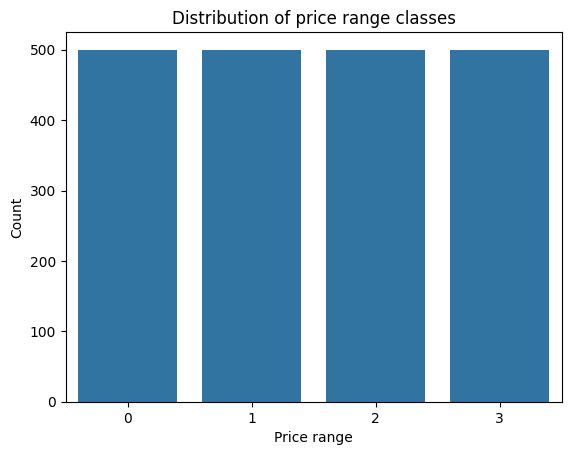

In [14]:
sns.countplot(x=label_df)
plt.title("Distribution of price range classes")
plt.xlabel("Price range")
plt.ylabel("Count")
plt.show()

Encode your classes into a numerical variable.

**Classes are already in numerical format.**


Check if your data and classes are numpy arrays. If that is not the case, transform your data and classes into numpy arrays.

In [15]:
print(type(scaled_variables_df))
print(type(label_df))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


**Neither of them are numpy arrays, so we have to transform them.**

In [7]:
scaled_variables_np = scaled_variables_df.to_numpy()
label_np = label_df.to_numpy()
print(type(scaled_variables_np))
print(type(label_np))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


### Clustering algorithm 1: K-means

Apply the K-means algorithm with 2 centers. Look at the default parameters the method takes. Make sure the algorithm doesn't run more than 500 iterations.

In [112]:
kmeans = KMeans(n_clusters=2, max_iter=500)

In [113]:
kmeans.fit(scaled_variables_np)

KMeans(max_iter=500, n_clusters=2)

What does the max_iter parameter do?

**From the scikit-learn documentation: the `max_iter` parameter specifies the maximum number of iterations of the k-means algorithm for a single run.**

How many samples are in each cluster?

In [114]:
cluster_labels = kmeans.labels_
cluster_labels_series = pd.Series(cluster_labels)
cluster_labels_series.value_counts().sort_index()

,count
0,1043
1,957


**There are 1043 samples in the first cluster and 957 in the second one.**

In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

For n_clusters = 2 The average silhouette_score is: 0.05353252039586674
For n_clusters = 3 The average silhouette_score is: 0.06558888754703945
For n_clusters = 4 The average silhouette_score is: 0.058013722537122635
For n_clusters = 5 The average silhouette_score is: 0.05419465678291909
For n_clusters = 6 The average silhouette_score is: 0.04691756531509089
For n_clusters = 7 The average silhouette_score is: 0.04380913611613645
For n_clusters = 8 The average silhouette_score is: 0.04702061462385386
For n_clusters = 9 The average silhouette_score is: 0.04485973750267945
For n_clusters = 10 The average silhouette_score is: 0.04616488957769495


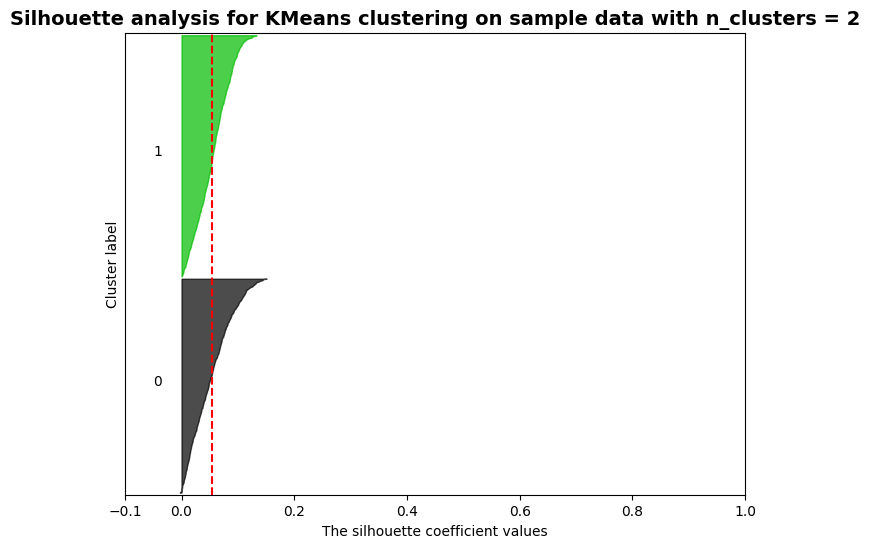

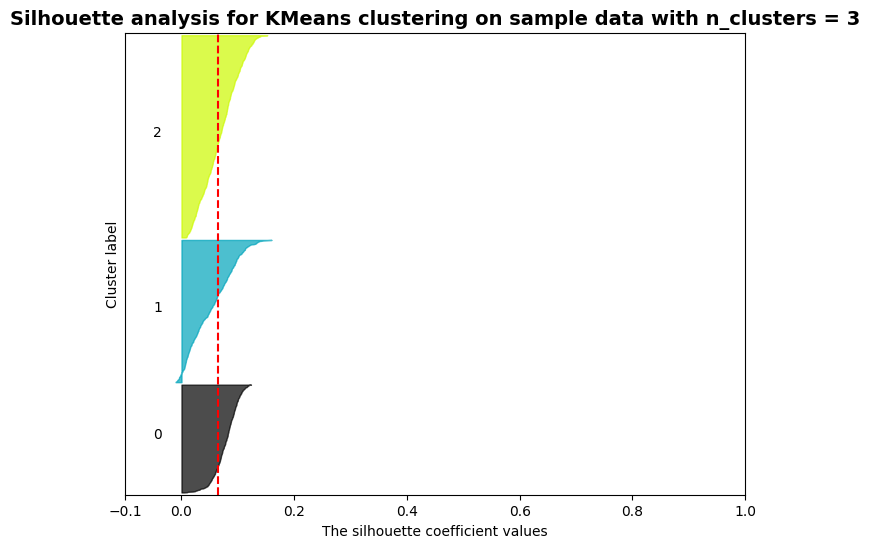

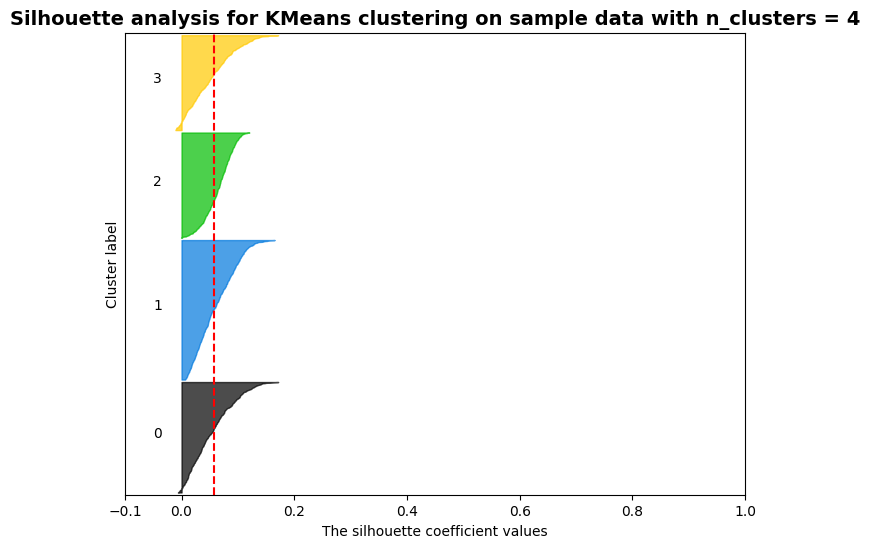

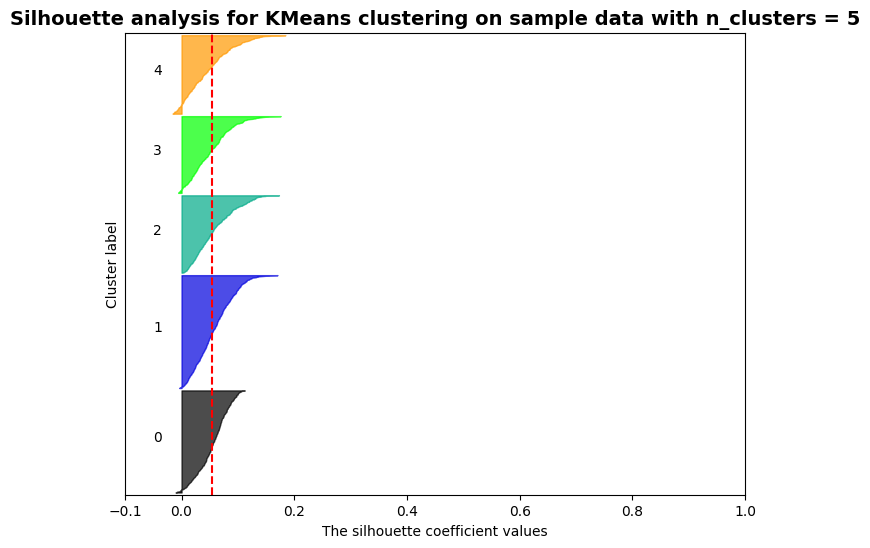

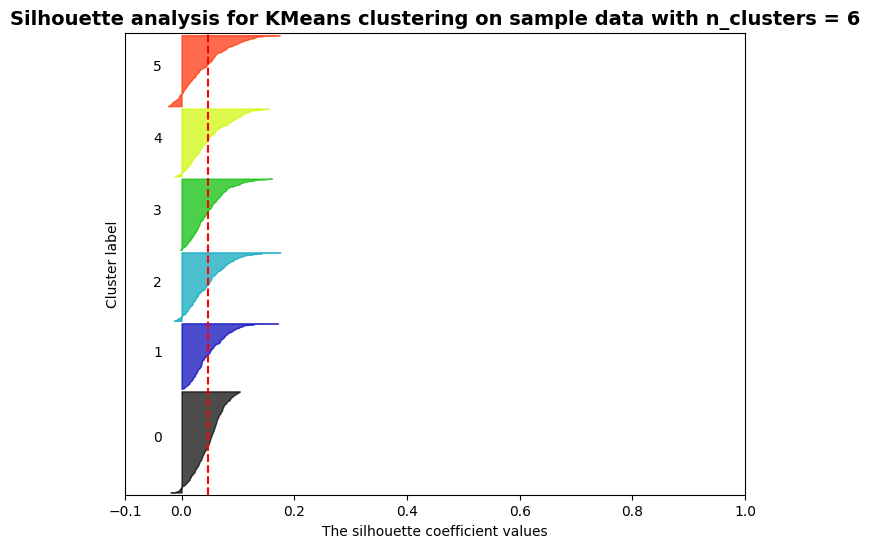

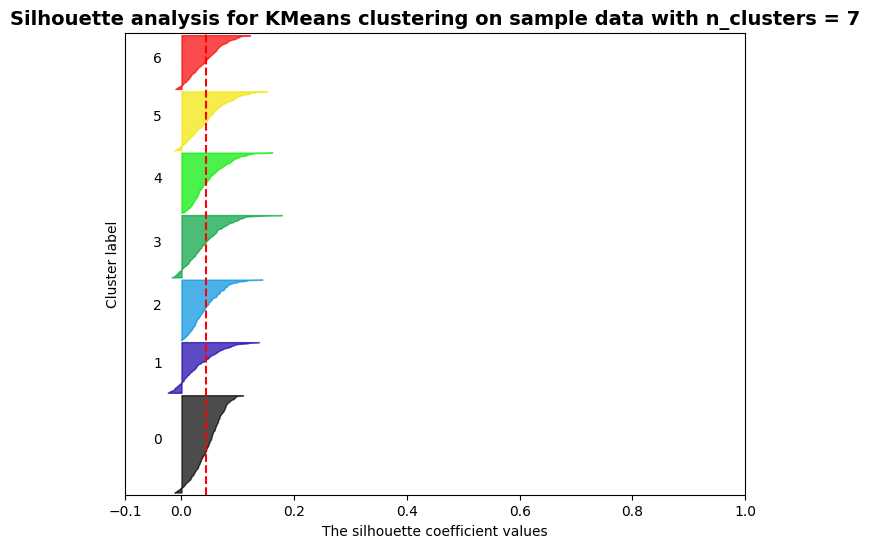

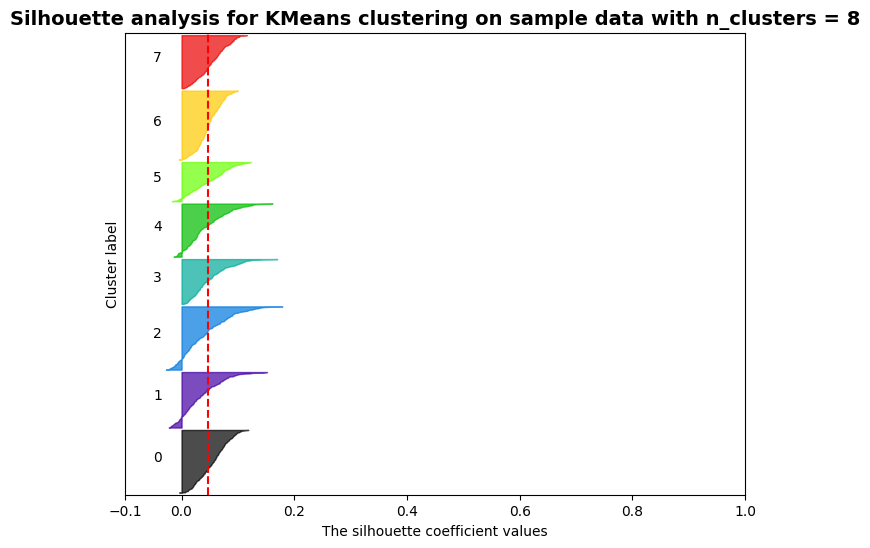

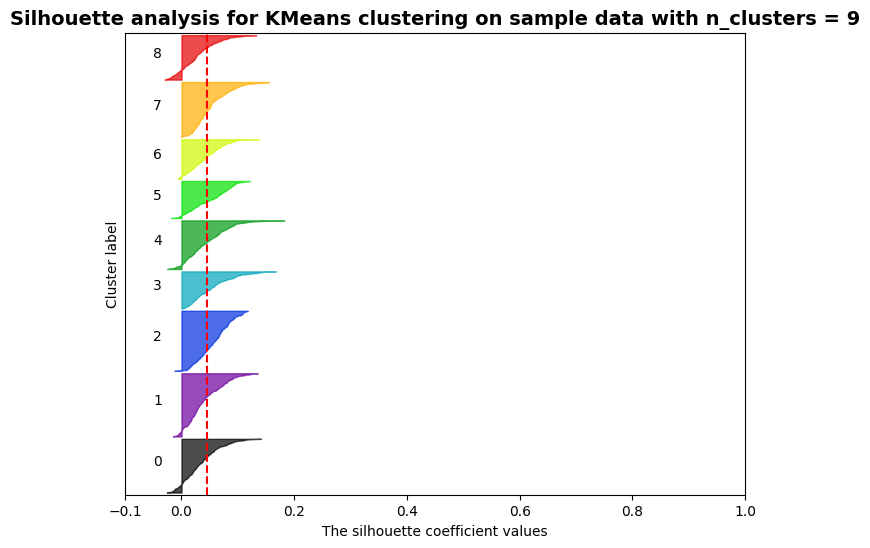

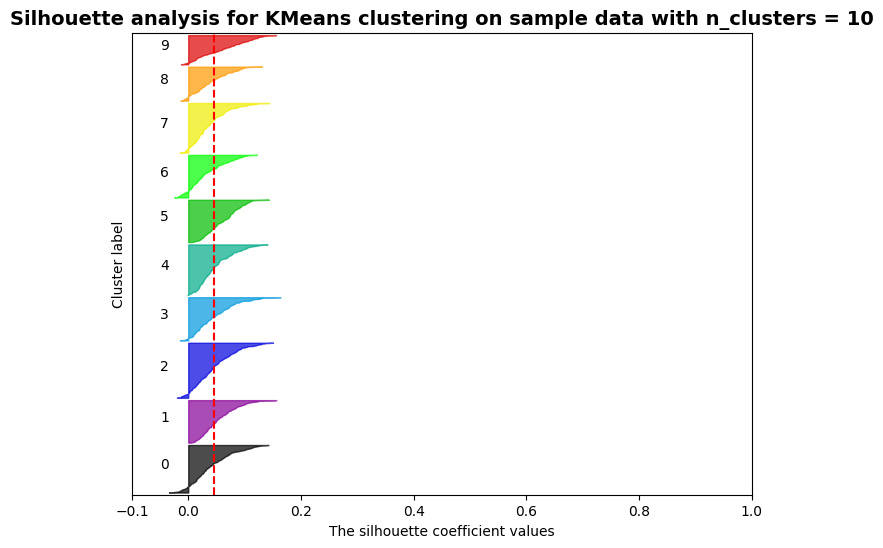

In [115]:
range_n_clusters = range(2, 11)

import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

for n_clusters in range_n_clusters:
    # Create a plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    # This plot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax.set_ylim([0, len(scaled_variables_np) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters.
    clusterer = KMeans(n_clusters=n_clusters, max_iter=500)
    cluster_labels = clusterer.fit_predict(scaled_variables_np)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(scaled_variables_np, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is:", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(scaled_variables_np, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.title(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

What is, in your opinion, the best number of centers to choose?

**Based on the output, although all silhouettes scores are low, 3 centers appears to give the best one, which indicates better clustering with samples further away from neighboring clusters.**

**However, we also have to take into account the shape and the consistency of the silhouettes: plots similar in thickness and with low fluctuation indicate that the clusters are of similar sizes. With 3 clusters, cluster 0 is noticeably smaller than cluster 2 (the silhouette takes up less space on the Y axis).
With 2 centers, the silhouettes seem to have more consistent sizes, with a distribution nearing a 50/50 split. While it also yields a lower average score than 3 centers, all the scores being low and very close to each other, with differences in the thousandths or hundredths at most, makes this value overerall less significant than the shape and consistency of the silhouettes.**

**Going beyond 3 or 4 doesn't seem to improve the clustering quality either, and having too many centers is not ideal.
Thus, while the results are rather homogenous, we think 2 centers provides marginally more optimal clustering results. However, with all the average silhouette scores being very low, it is still unlikely that we obtain results of good quality regardless of the number of cluster centers used.**

Apply K-means again with the optimal number of centers.

In [133]:
kmeans_2 = KMeans(n_clusters=2, max_iter=500)
kmeans_2.fit(scaled_variables_np)

KMeans(max_iter=500, n_clusters=2)

How many samples are in each cluster?

In [134]:
cluster_2_labels = kmeans_2.labels_
cluster_2_labels_series = pd.Series(cluster_2_labels)
cluster_2_labels_series.value_counts().sort_index()

,count
0,957
1,1043


**There are 957 samples in the first cluster and 1043 in the second one.**

Since, the true class of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [137]:
contingency_matrix_kmeans = pd.crosstab(label_df, cluster_2_labels, rownames=["True classes"], colnames=["KMeans clusters"])
display(contingency_matrix_kmeans)

KMeans clusters,0,1
True classes,,
0,241,259
1,238,262
2,253,247
3,225,275


2- Discuss the obtained matrix

**The contingency matrix we obtained shows the relationship between the true classes and the clusters we computed. It displays the count of samples that fall into each combination of true class and cluster.**

**We can see that for each class, the number of samples that belong to that class are nearly equally split between both clusters, which indicates that the k-means clustering with 2 centers did not separate the data in an efficient way.**

**Since we have 4 true classes and 2 clusters, ideally we would have expected each cluster to have most of its samples concentrated into 2 true classes, meaning the results provided by the clustering would have been aligned with the true classes.**

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [144]:
from sklearn.metrics import rand_score, adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score
rand = rand_score(label_np, cluster_2_labels)
print("Rand index:", rand)

Rand index: 0.49968434217108554


In [146]:
adjusted_rand = adjusted_rand_score(label_np, cluster_2_labels)
print("Adjusted rand index:", adjusted_rand)

Adjusted rand index: 4.4504445052505136e-05


In [147]:
homogenity = homogeneity_score(label_np, cluster_2_labels)
print("Homogeneity score:", homogenity)

Homogeneity score: 0.0005737978593281727


In [148]:
completeness = completeness_score(label_np, cluster_2_labels)
print("Completeness score:", completeness)

Completeness score: 0.001149128866732807


In [149]:
v_measure = v_measure_score(label_np, cluster_2_labels)
print("V-measure score:", v_measure)

V-measure score: 0.000765404208838254


4- Discuss the obtained scores.

* **`Rand index:` a score of ~0.5 suggests that the alignment between the k-means clusters and the true classes is roughly equivalent to what we would expect by random chance.**

* **`Adjusted rand index:` the score is very close to 0, which once again indicates that the alignment is no better than random chance.**

* **`Homogeneity:` the homogeneity score is also very close to 0, meaning the clusters are not pure and contain samples from multiple true price range classes, as seen earlier in the contingency matrix.**

* **`Completeness:` the completeness score is also very close to 0, meaning the samples that belong to the same true price range class are not being assigned to the same cluster, but are spread across both clusters, as seen earlier in the contingency matrix.**

* **`V-measure:` this score is a harmonic mean of homogeneity and completeness, and as expected it is also very close to 0, since it reflects the same conclusions drawn from the previous 2 scores.**

**Overall, these scores confirm what we had determined from the slihouette analysis and the contingency matrix: while the k-means algorithm with 2 cluster centers did manage to form groups of similar sizes, it did not separate the data efficiently, as the samples from one cluster center are not far away enough from the other (low average silhouette score), and clustering results do not match the classes from the `price_range` label.**

### Clustering algorithm 2: Hierarchical clustering

Apply the hierarchical clustering algorithm with 2 centers. Look at the default parameters and make sure the algorithm is based on the single linkage method.

In [154]:
hclust = AgglomerativeClustering(n_clusters=2, linkage="single")

In [155]:
hclust.fit(scaled_variables_np)

AgglomerativeClustering(linkage='single')

How many samples are in each cluster?

In [156]:
hcluster_labels = hclust.labels_
hcluster_labels_series = pd.Series(hcluster_labels)
hcluster_labels_series.value_counts().sort_index()

,count
0,1999
1,1


**There are 1999 samples in the first cluster and only 1 in the second one.**

Apply the hierarchical clustering algorithm again. This time,  change the linkage method to complete linkage.

In [158]:
hclust_complete = AgglomerativeClustering(n_clusters=2, linkage="complete")

In [161]:
hclust_complete.fit(scaled_variables_np)

AgglomerativeClustering(linkage='complete')

How many samples are in each cluster?

In [162]:
hcluster_complete_labels = hclust_complete.labels_
hcluster_complete_labels_series = pd.Series(hcluster_complete_labels)
hcluster_complete_labels_series.value_counts().sort_index()

,count
0,773
1,1227


**There are now 773 samples in the first cluster and 1227 in the second one.**

Apply the hierarchical clustering algorithm once again. This time, change the linkage method to ward linkage.

In [163]:
hclust_ward = AgglomerativeClustering(n_clusters=2, linkage="ward")

In [164]:
hclust_ward.fit(scaled_variables_np)

AgglomerativeClustering()

How many samples are in each cluster?

In [165]:
hcluster_ward_labels = hclust_ward.labels_
hcluster_ward_labels_series = pd.Series(hcluster_ward_labels)
hcluster_ward_labels_series.value_counts().sort_index()

,count
0,1513
1,487


**There are now 1513 samples in the first cluster and 487 in the second one.**

Compare the three results. Is the type of linkage method used important? Which one gave you the best result? For the rest of this section, use the best linkage method.

* **`Single linkage:` cluster sizes are 1999 and 1. This results in a highly imbalanced clustering, where almost all samples are in one cluster and only one sample is in the other.**

* **`Complete linkage:` cluster sizes are 773 and 1227. This provides a more balanced distribution of samples between the two clusters compared to single linkage.**

* **`Ward linkage:` cluster sizes are 1513 and 487. This also provides a more balanced distribution than single linkage, though slightly less balanced than complete linkage.**

**Based on these results, the linkage method that is used is indeed very important. Different linkage methods can lead to significantly different cluster sizes.**

**Complete linkage gave the best results here, with a more balanced distribution of samples across the 2 clusters, so we are going to use it for the rest of this section.**

In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

For n_clusters = 2 The average silhouette_score is: 0.027422733878544735
For n_clusters = 3 The average silhouette_score is: 0.02077229211822391
For n_clusters = 4 The average silhouette_score is: 0.012454088756040265
For n_clusters = 5 The average silhouette_score is: 0.01911175142474598
For n_clusters = 6 The average silhouette_score is: 0.014478548241944568
For n_clusters = 7 The average silhouette_score is: 0.012774498126818624
For n_clusters = 8 The average silhouette_score is: 0.009273310705575253
For n_clusters = 9 The average silhouette_score is: 0.008860507197306603
For n_clusters = 10 The average silhouette_score is: 0.007130531717622419


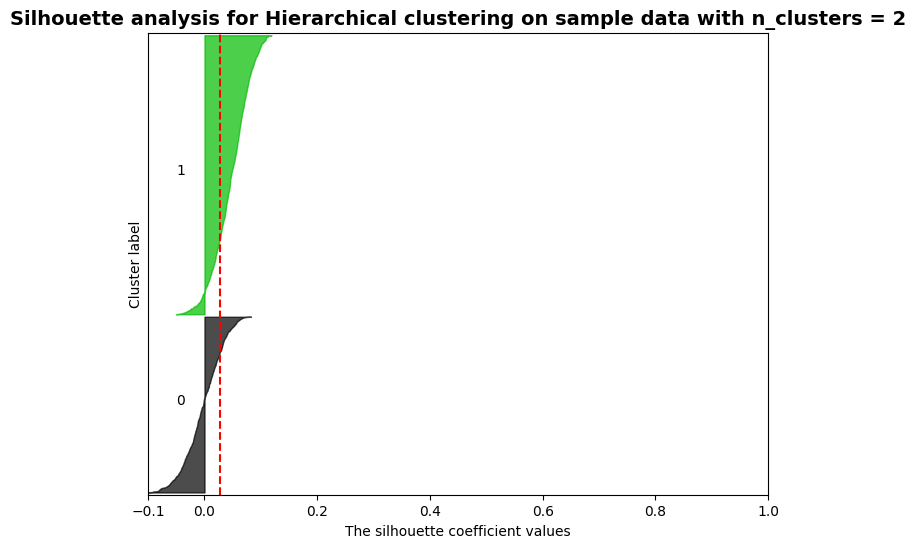

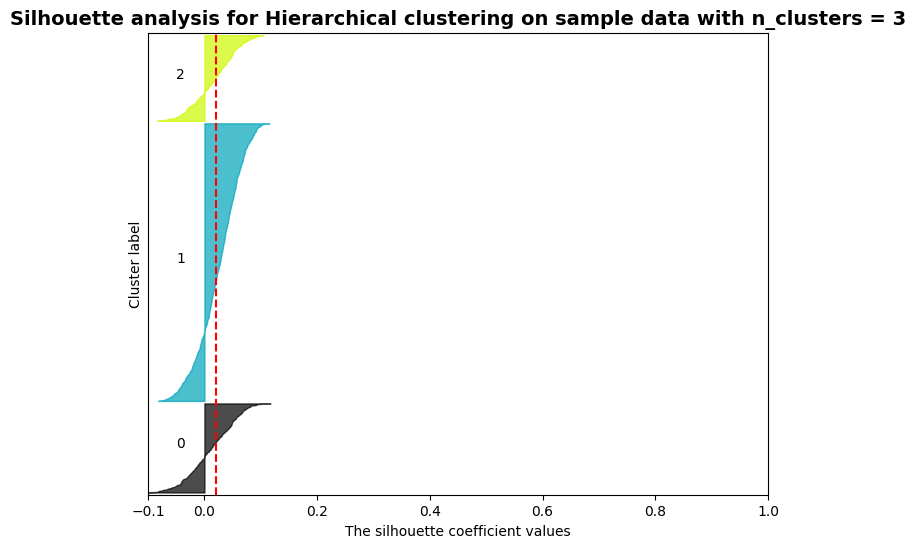

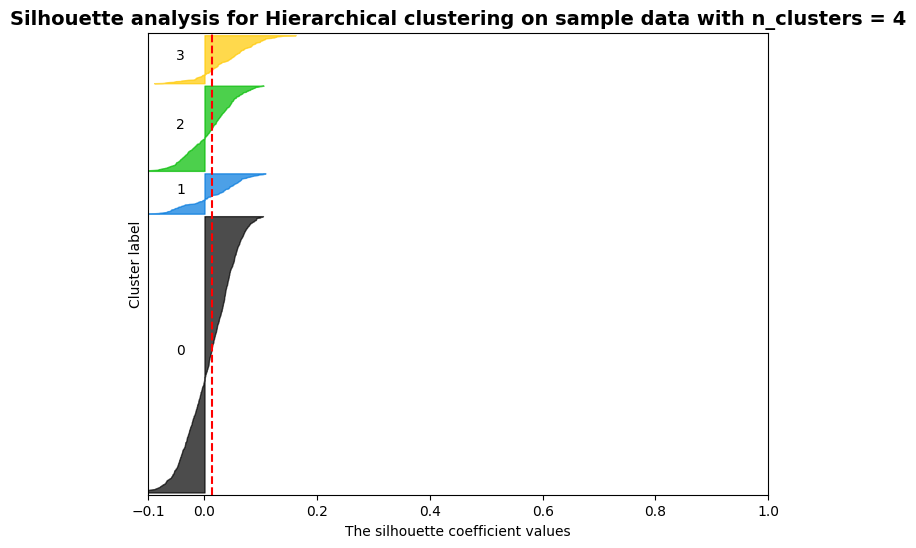

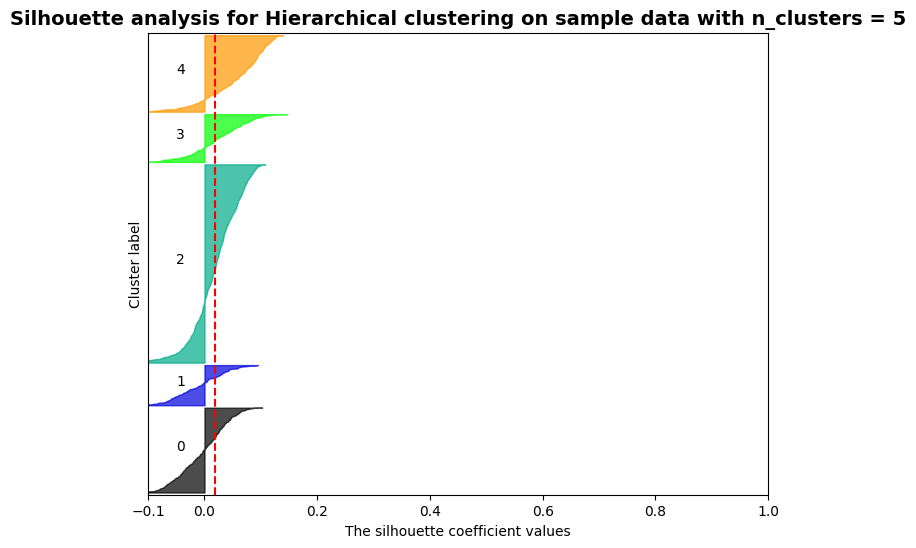

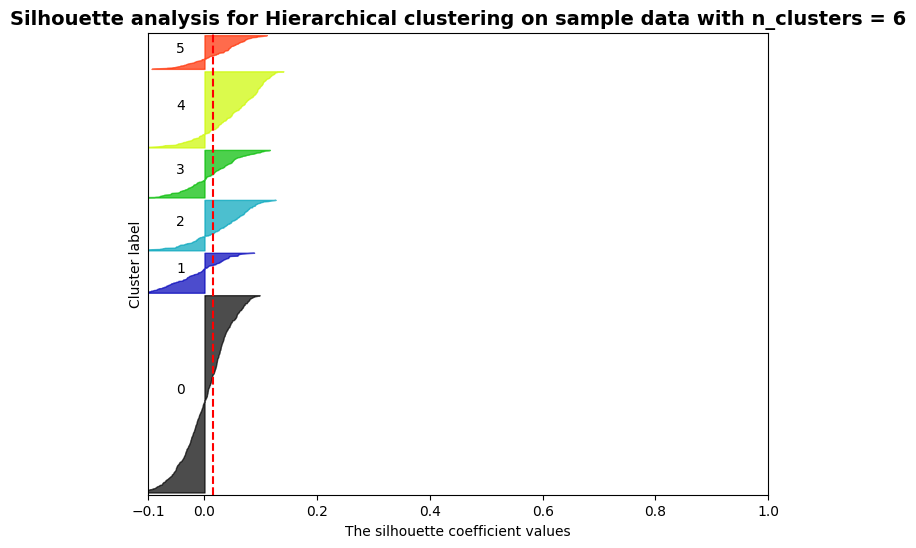

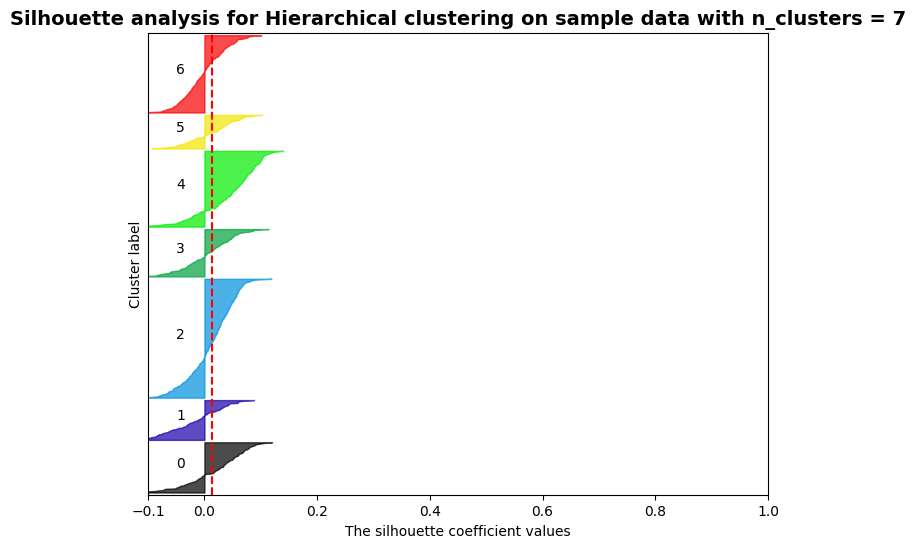

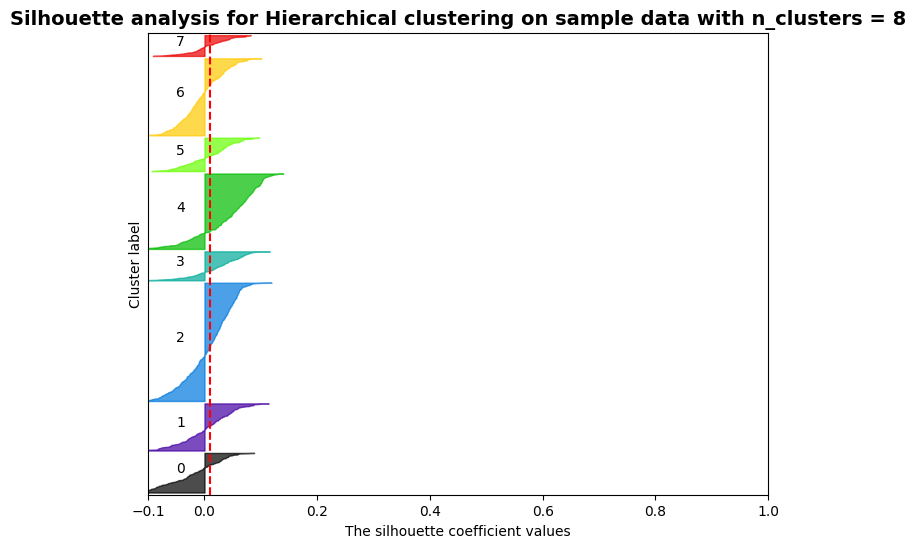

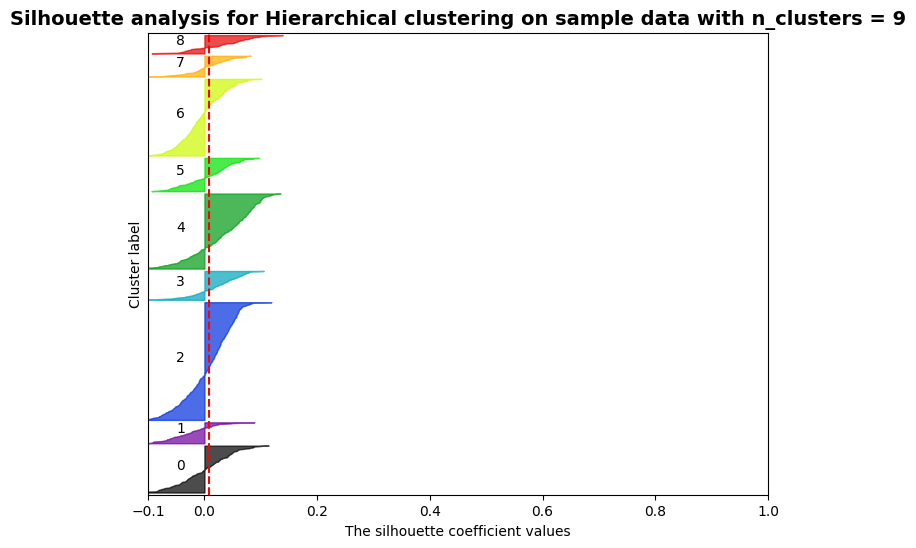

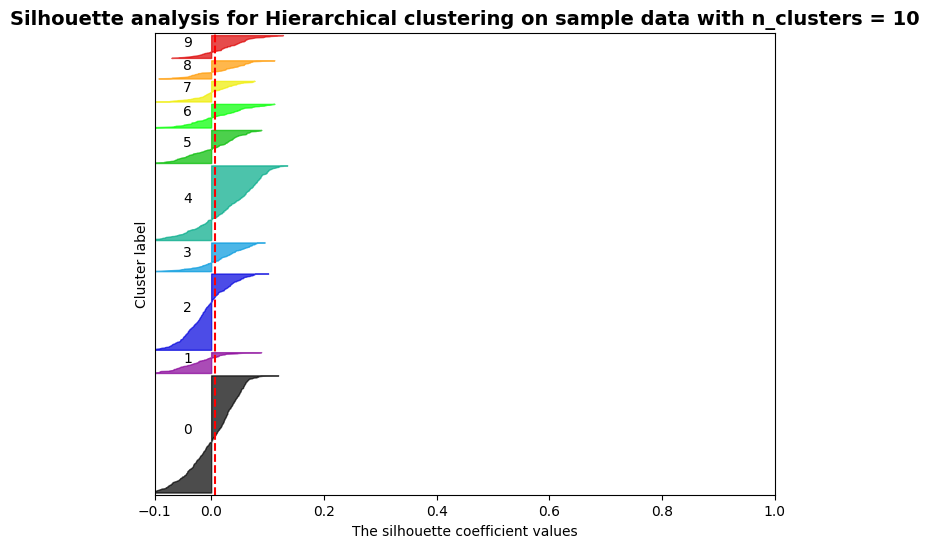

In [167]:
range_n_clusters = range(2, 11)

import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

for n_clusters in range_n_clusters:
    # Create a plot
    fig, ax  = plt.subplots(1, 1, figsize=(8,6))

    # This plot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax.set_ylim([0, len(scaled_variables_np) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters and the linkage method you
    # determined worked best.
    clusterer =  AgglomerativeClustering(n_clusters=n_clusters, linkage="complete")
    cluster_labels = clusterer.fit_predict(scaled_variables_np)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(scaled_variables_np, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is:", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(scaled_variables_np, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.title(("Silhouette analysis for Hierarchical clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

What is, in your opinion, the best number of centers to choose?

**Like for k-means clustering, all the average silhouette scores we obtain are very low, so even though 2 cluster centers provides the best one, we also have to rely on the size and shape of the silhouettes.**

**We can see that every plot shows at least one silhouette that is disproportionately larger than the others. All of them also have part of their samples scoring negative silhouette scores, which means they might have been assigned to the wrong cluster altogether.**

**Based on these observations, the most optimal number of centers would likely be the one for which the silhouettes are of similar sizes (as much as possible in our case), have as much of their samples above their average score line, and as least of their samples below 0 as possible.**

**With 2 centers, the silhouettes are closer in size, center 0 has half of its samples scoring below 0, while center 1 only has a few. 3 and 5 both present one center that is much larger than the others, however they retain close enough average silhouette scores, and with 3 centers specifically, all silhouettes have more samples scoring above 0 than below, which is not the case for 2 or 5. We believe this makes up for the previously mentioned discrepancy in sizes, as like explained earlier, all the samples with negative scores in the center 0 of the 2 centers option might just as well be reassigned to the other cluster, which could result in that same descrepancy.**

**Hence, while none of the numbers provide a satisfactory answer and suggest once again that the clustering results are likely to be poor regardless of the choice, we think 3 centers yields a marginally more optimal solution.**

Apply hierarchical clustering again with the optimal number of centers.

In [48]:
hclust_3 = AgglomerativeClustering(n_clusters=3, linkage="complete")
hclust_3.fit(scaled_variables_np)

AgglomerativeClustering(linkage='complete', n_clusters=3)

How many samples are in each cluster?

In [49]:
hcluster_3_labels = hclust_3.labels_
hcluster_3_labels_series = pd.Series(hcluster_3_labels)
hcluster_3_labels_series.value_counts().sort_index()

,count
0,394
1,1227
2,379


**There are 394 samples in the first cluster, 1227 in the second one and 379 in the third one.**

Since, the true class of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [185]:
contingency_matrix_hclust = pd.crosstab(label_df, hcluster_3_labels, rownames=["True classes"], colnames=["Hierarchical clusters"])
display(contingency_matrix_hclust)

Hierarchical clusters,0,1,2
True classes,,,
0,39,362,99
1,88,303,109
2,98,310,92
3,169,252,79


2- Discuss the obtained matrix.

**Similar to the k-means results, the hierarchical clustering with 3 centers did not effectively separate the data according to the true classes of the `price_range` label: each cluster contains a significant number of samples from multiple true classes, and each true class always has most of its samples in the same cluster (cluster 1).**

**Cluster 0 does have a high concentration of samples in the true class 3 (169), possibly indicating a partial match, but since it is the only one with a difference this clear, this is no more conclusive than what we could expect by chance.**

**Since we have 4 true classes and 3 clusters, ideally we would have expected each cluster to have most of its samples concentrated into 1 or at most 2 of the true classes, which is not the case here.**

**In conclusion, there is still no considerable overlap between the hierarchical clusters and the true classes.**

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [186]:
rand = rand_score(label_np, hcluster_3_labels)
print("Rand index:", rand)

Rand index: 0.5318014007003502


In [187]:
adjusted_rand = adjusted_rand_score(label_np, hcluster_3_labels)
print("Adjusted rand index:", adjusted_rand)

Adjusted rand index: 0.015099522761203975


In [188]:
homogenity = homogeneity_score(label_np, hcluster_3_labels)
print("Homogeneity score:", homogenity)

Homogeneity score: 0.02062087590471669


In [189]:
completeness = completeness_score(label_np, hcluster_3_labels)
print("Completeness score:", completeness)

Completeness score: 0.030574387643359624


In [190]:
v_measure = v_measure_score(label_np, hcluster_3_labels)
print("V-measure score:", v_measure)

V-measure score: 0.024630038396593522


4- Discuss the obtained scores.

**The results and the conclusions we can draw from them are similar to those using k-means clustering:**

* **`Rand index:` a score of ~0.5 suggests that the alignment between the hierarchical clusters and the true classes is roughly equivalent to what we would expect by random chance.**

* **`Adjusted rand index:` the score is very close to 0, which once again indicates that the alignment is no better than random chance.**

* **`Homogeneity:` the homogeneity score is also very close to 0, meaning the clusters are not pure and contain samples from multiple true price range classes, as seen earlier in the contingency matrix.**

* **`Completeness:` the completeness score is also very close to 0, meaning the samples that belong to the same true price range class are not being assigned to the same cluster, but are spread across all three clusters, as seen earlier in the contingency matrix.**

* **`V-measure:` this score is a harmonic mean of homogeneity and completeness, and as expected it is also very close to 0, since it reflects the same conclusions drawn from the previous 2 scores.**

**Overall, like with k-means, these scores confirm what we had determined from the slihouette analysis and the contingency matrix: the hierarchical clustering algorithm did not separate the data efficiently, as the samples from one cluster center are not far away enough from the others (low average silhouette score), and clustering results do not match the classes from the `price_range` label.**

OPTIONAL: plot the dendrogram

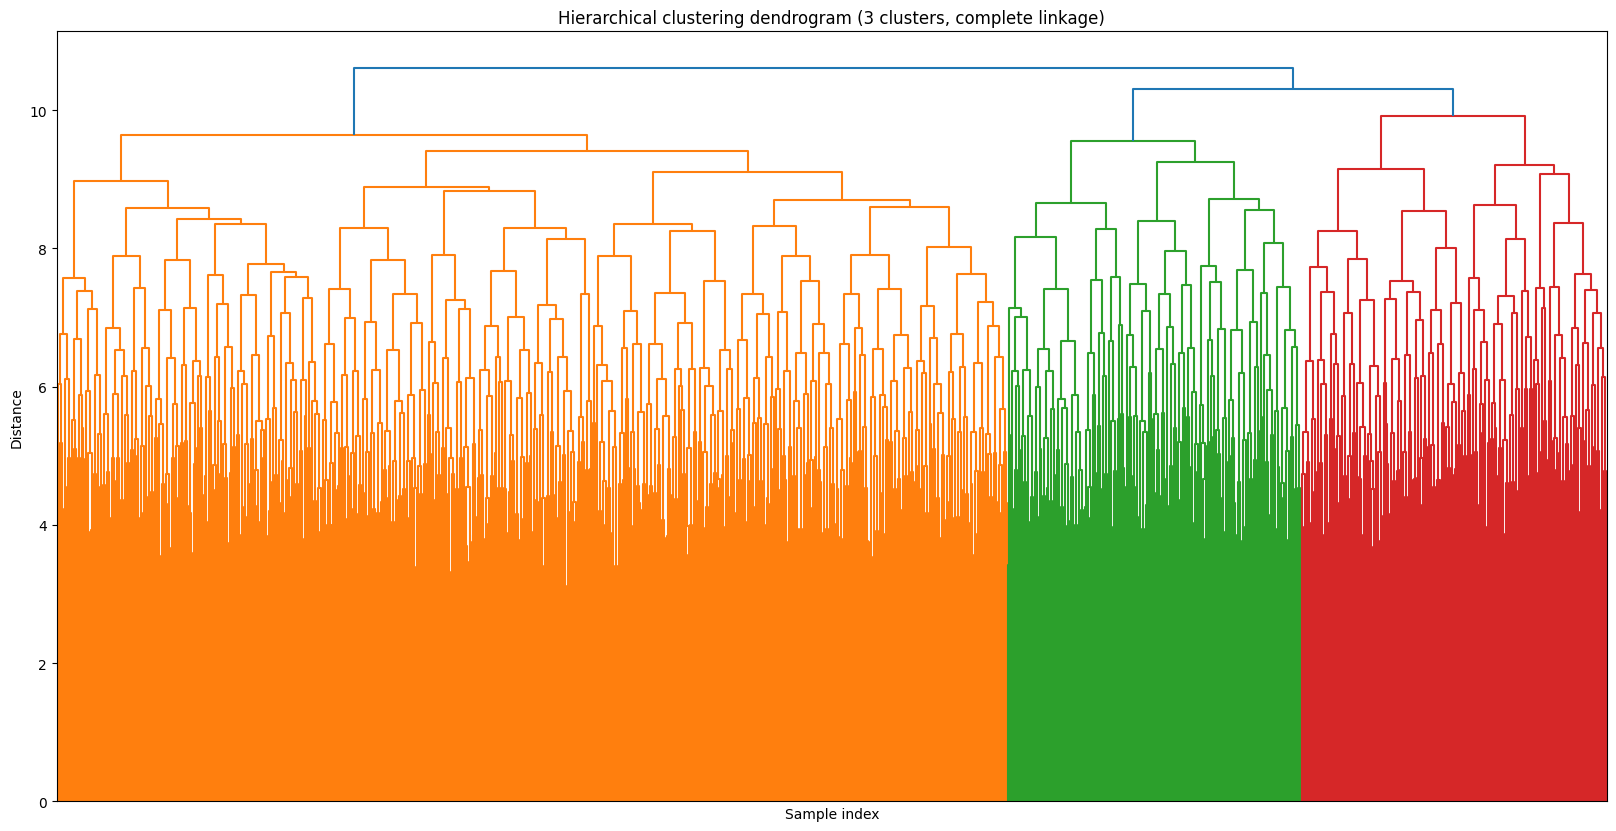

In [218]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate the hierarchical clustering encoded as a linkage matrix
linkage_matrix = linkage(scaled_variables_np, "complete")

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linkage_matrix,
           # Set the cut threshold at a distance where drawing a horizontal line makes it go through 3 branches to see the 3 uniquely colored clusters
           color_threshold=10,
           # Hide leaf labels as there are too many for any of them to be legible
           no_labels=True)
plt.title("Hierarchical clustering dendrogram (3 clusters, complete linkage)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

## TD3 (part II): Spectral clustering and comparison

### Clustering algorithm 3: Spectral clustering

Apply the spectral clustering algorithm with 2 centers.

In [22]:
spectral_clust = SpectralClustering(n_clusters=2)

In [23]:
spectral_clust.fit(scaled_variables_np)

SpectralClustering(n_clusters=2)

How many samples are in each cluster?

In [24]:
spectral_cluster_labels = spectral_clust.labels_
spectral_cluster_labels_series = pd.Series(spectral_cluster_labels)
spectral_cluster_labels_series.value_counts().sort_index()

,count
0,1994
1,6


**There are 1994 samples in the first cluster and only 6 in the second one.**

Apply the spectral clustering algorithm again. This time, change the method to construct the affinity matrix to "nearest_neighbors".

In [25]:
spectral_clust_nearest = SpectralClustering(n_clusters=2, affinity="nearest_neighbors")

In [26]:
spectral_clust_nearest.fit(scaled_variables_np)

SpectralClustering(affinity='nearest_neighbors', n_clusters=2)

How many samples are in each cluster?

In [27]:
spectral_cluster_nearest_labels = spectral_clust_nearest.labels_
spectral_cluster_nearest_labels_series = pd.Series(spectral_cluster_nearest_labels)
spectral_cluster_nearest_labels_series.value_counts().sort_index()

,count
0,1518
1,482


**There are now 1518 samples in the first cluster and 482 in the second one.**

Compare the two results. Is the method used to construct the affinity matrix important? Which one gave you the best result? For the rest of this section, use the best method.

* **`rbf affinity (default):` cluster sizes are 1994 and 6. This results in a highly imbalanced clustering, where almost all samples are in one cluster and very few are in the other.**

* **`nearest_neighbors affinity:` cluster sizes are 1518 and 482. This provides a significantly more balanced distribution of samples between the two clusters compared to the default method.**

**Based on these results, the affinity method that is used is indeed very important. Different affinity methods can lead to significantly different cluster sizes.**

**`nearest_neighbors` affinity definitely gave the best results here, with a much more balanced distribution, so we are going to use it for the rest of this section.**

In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

For n_clusters = 2 The average silhouette_score is : 0.08394543726210128
For n_clusters = 3 The average silhouette_score is : 0.06076816914697938
For n_clusters = 4 The average silhouette_score is : 0.050144580110737136
For n_clusters = 5 The average silhouette_score is : 0.04047240651721563
For n_clusters = 6 The average silhouette_score is : 0.037674003534829484
For n_clusters = 7 The average silhouette_score is : 0.03659934674267885
For n_clusters = 8 The average silhouette_score is : 0.03711380605768984
For n_clusters = 9 The average silhouette_score is : 0.03787521735867477
For n_clusters = 10 The average silhouette_score is : 0.03507873081954415


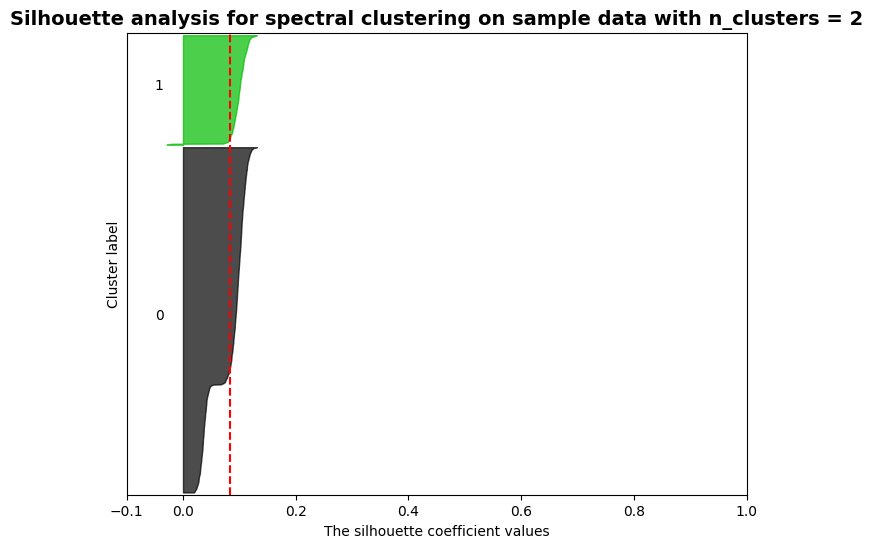

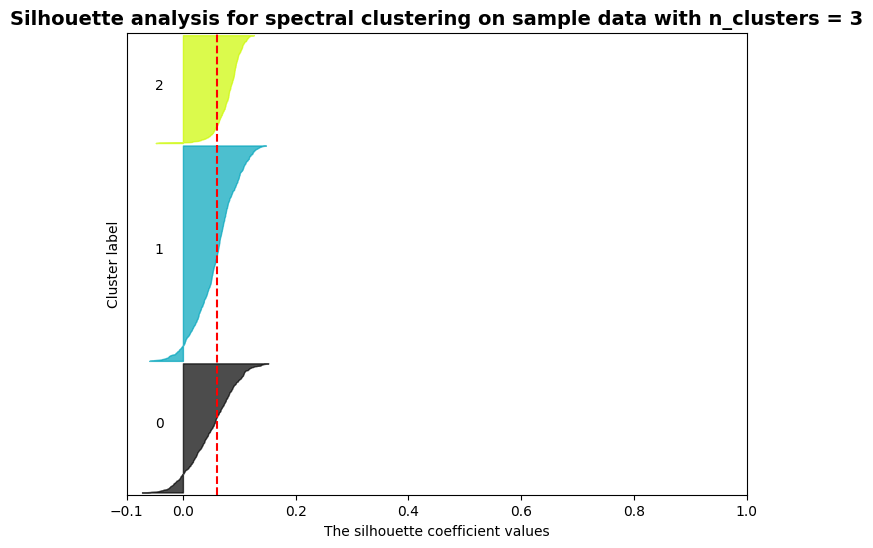

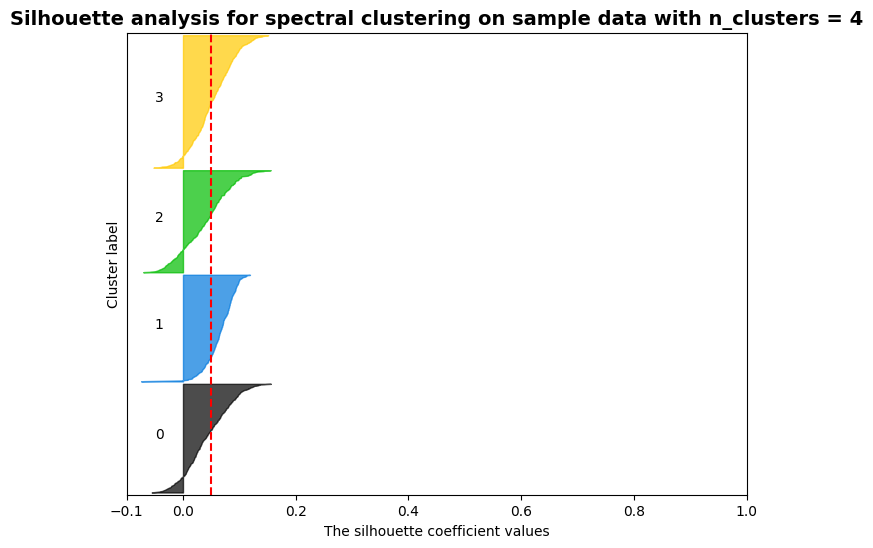

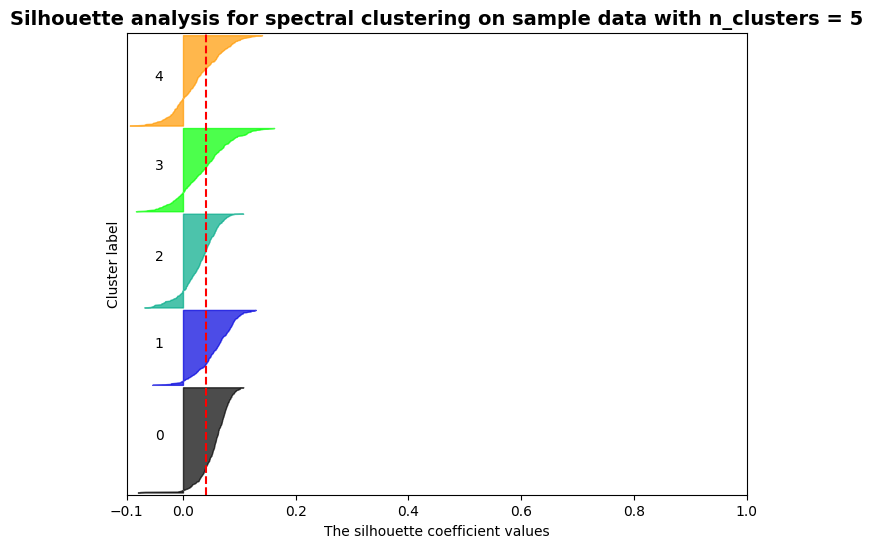

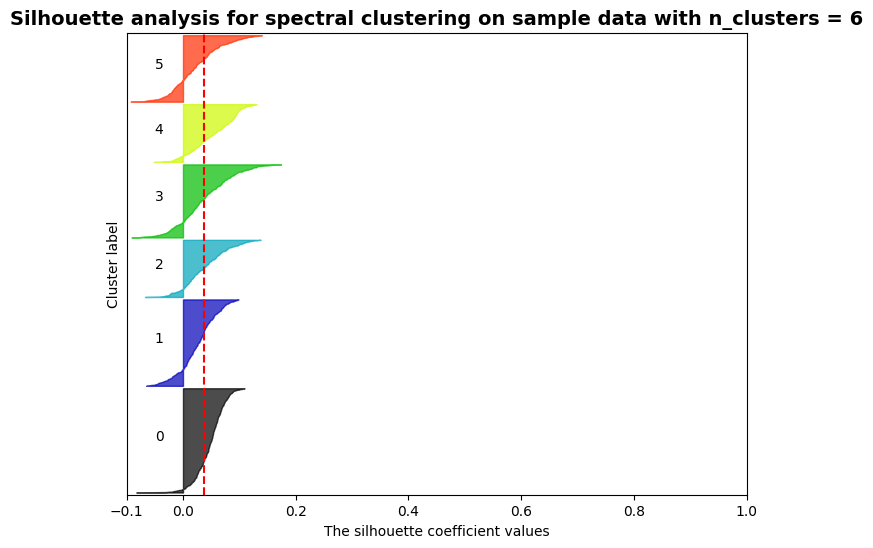

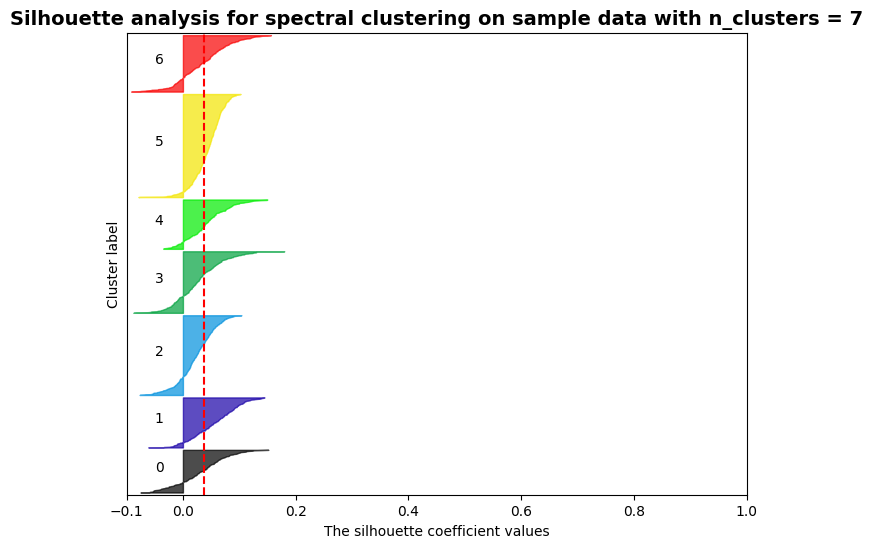

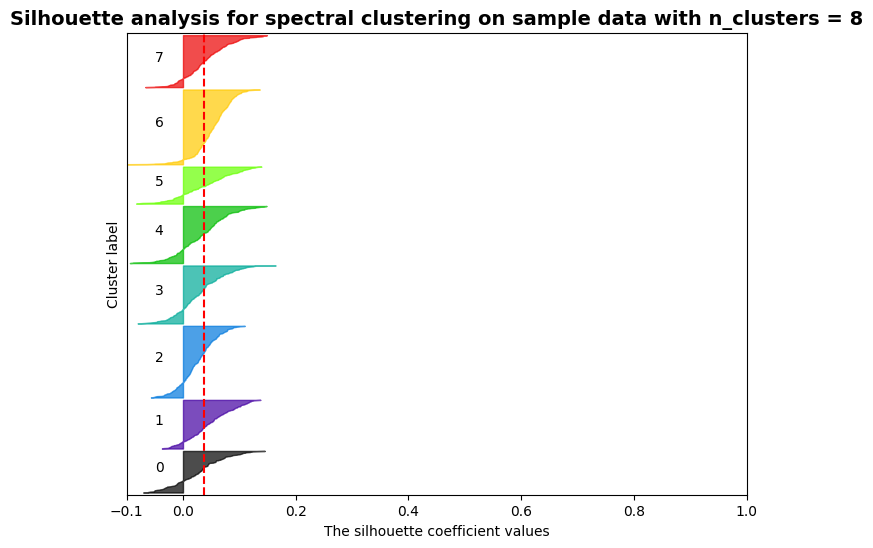

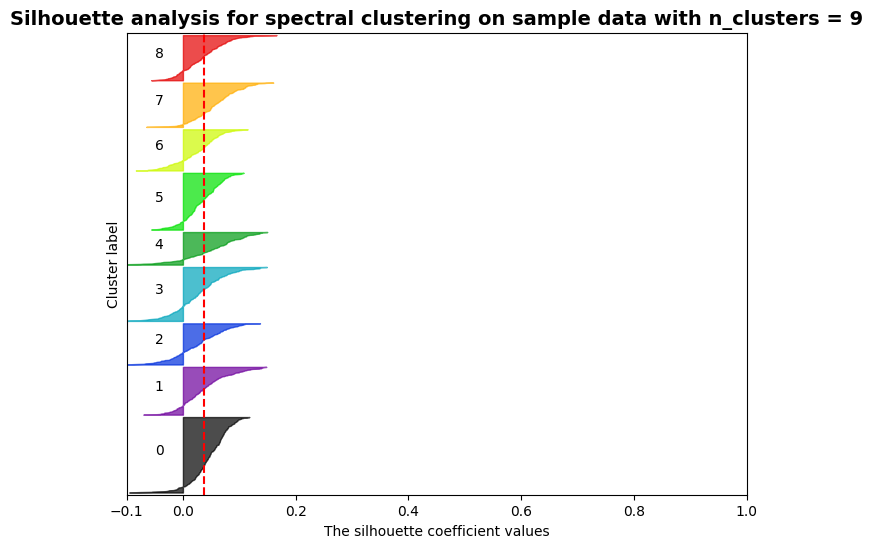

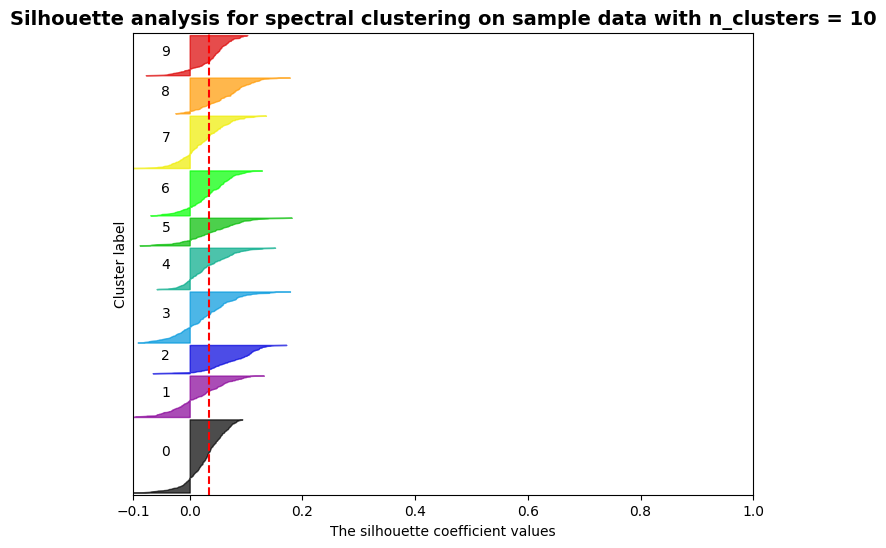

In [33]:
range_n_clusters = range(2, 11)

import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

for n_clusters in range_n_clusters:
    # Create a plot
    fig, ax = plt.subplots(1, 1, figsize=(8,6))

    # This plot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax.set_ylim([0, len(scaled_variables_np) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters. Make sure you use the "affinity"
    # method that gave you the best results.
    clusterer = SpectralClustering(n_clusters=n_clusters, affinity="nearest_neighbors")
    cluster_labels = clusterer.fit_predict(scaled_variables_np)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(scaled_variables_np, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(scaled_variables_np, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.title(("Silhouette analysis for spectral clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

What is, in your opinion, the best number of centers to choose?

**Like for k-means and hierarchical clustering, all the average silhouette scores we obtain are very low. Even though 2 cluster centers provides the best one, we also have to rely on the size and shape of the silhouettes.**

**All the silhouettes have most of their samples scoring above 0, so we will focus on the consistency of their sizes. We can see that 2 and 3 both have 1 silhouette that is much larger than the others, which leads to a less balanced distribution. 2 also has less of its samples scoring above the corresponding average score.**

**In comparison, 4 and 5 centers (and beyond) provide more consistent and evenly spread out silhouettes, with more samples scoring above average.**

**Since going beyond 4 doesn't offer much more consistency but still slightly lowers the score, we think this number of centers would yield marginally more optimal results. However, once again, none of the numbers provide a satisfactory answer and suggest that the clustering results are likely to be poor regardless of the choice.**

Apply spectral clustering again with the optimal number of centers.

In [34]:
spectral_clust_4 = SpectralClustering(n_clusters=4, affinity="nearest_neighbors")

In [35]:
spectral_clust_4.fit(scaled_variables_np)

SpectralClustering(affinity='nearest_neighbors', n_clusters=4)

How many samples are in each cluster?

In [36]:
spectral_cluster_4_labels = spectral_clust_4.labels_
spectral_cluster_4_labels_series = pd.Series(spectral_cluster_4_labels)
spectral_cluster_4_labels_series.value_counts().sort_index()

,count
0,443
1,488
2,471
3,598


**There are 443 samples in the first cluster, 488 in the second one, 471 in the third one, and 598 in the fourth one. As we can see, the samples are more evenly distributed than with 2 clusters.**

Since, the true label of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [37]:
contingency_matrix_spectral = pd.crosstab(label_df, spectral_cluster_4_labels, rownames=["True classes"], colnames=["Spectral clusters"])
display(contingency_matrix_spectral)

Spectral clusters,0,1,2,3
True classes,,,,
0,88,113,127,172
1,108,123,120,149
2,122,118,114,146
3,125,134,110,131


2- Discuss the obtained matrix.

**Like k-means and hierarchical clustering, spectral clustering did not manage to separate the data in an efficient way according to the true classes of the `price_range` label: none of the spectral clusters correspond cleanly to one single true class. Instead, they are spread out across the true classes, and each cluster contains a significant number of samples from multiple true classes.**

**This time, since we have an equal number of true classes and spectral clusters, ideally we would have expected results that approach a diagonal matrix, or one that could be reorganized into a diagonal matrix (since the numbers assigned to the true classes and clusters aren't necessarily the same). This would have shown a clear overlap between the computed clusters and the true price range classes.**

**In conclusion, there is still no considerable overlap between the spectral clusters and the true classes.**

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [41]:
rand = rand_score(label_np, spectral_cluster_4_labels)
print("Rand index:", rand)

Rand index: 0.624143571785893


In [42]:
adjusted_rand = adjusted_rand_score(label_np, spectral_cluster_4_labels)
print("Adjusted rand index:", adjusted_rand)

Adjusted rand index: 0.0013320177375039973


In [43]:
homogeneity = homogeneity_score(label_np, spectral_cluster_4_labels)
print("Homogeneity score:", homogeneity)

Homogeneity score: 0.0030704431368235993


In [44]:
completeness = completeness_score(label_np, spectral_cluster_4_labels)
print("Completeness score:", completeness)

Completeness score: 0.003085371027900542


In [45]:
v_measure = v_measure_score(label_np, spectral_cluster_4_labels)
print("V-measure score:", v_measure)

V-measure score: 0.003077888982243545


4- Discuss the obtained scores.

**The results and the conclusions we can draw from them are once again similar to those using k-means and hierarchical clustering:**

* **`Rand index:` this time, the score is very slightly higher and above 0.5, possibly suggesting there might be some level of agreement between the spectral clusters and the true classes, as 0.62 is marginally higher than what would be expected purely by chance (~0.5). However, to get a more reliable measure and know if this is meaningful at all, we have to look at the adjusted rand index, as it accounts for random chance.**

* **`Adjusted rand index:` the score is very close to 0, indicating that after accounting for chance, the previously mentioned agreement is negligible, and the alignment is actually no better than random chance.**

* **`Homogeneity:` the homogeneity score is also very close to 0, meaning the clusters are not pure and contain samples from multiple true price range classes, as seen earlier in the contingency matrix.**

* **`Completeness:` the completeness score is also very close to 0, meaning the samples that belong to the same true price range class are not being assigned to the same cluster, but are spread across all four clusters, as seen earlier in the contingency matrix.**

* **`V-measure:` this score is a harmonic mean of homogeneity and completeness, and as expected it is also very close to 0, since it reflects the same conclusions drawn from the previous 2 scores.**

**Overall, these scores confirm what we had determined from the slihouette analysis and the contingency matrix: the spectral clustering algorithm did not separate the data efficiently either, as the samples from one cluster center are not far away enough from the others (low average silhouette score), and clustering results do not match the classes from the `price_range` label.**

### Conclusion

In your opinion, which method gave the better results for this dataset?

**Based on the results we have obtained from each clustering method, none of them provided good results for this dataset in terms of aligning with the true price range classes:**

* **`Silhouette analyses:` for all 3 methods, the average silhouette scores were consistently very low (<0.1), and that regardless of the number of cluster centers. This means that even if we had chosen different numbers of clusters, we would likely not have obtained results that would be better in any significant way, as the samples from each cluster would still be way too close to the samples from other clusters.**

**If we have to select one clustering method as the "best" one for the silhouette analysis part alone, then spectral clustering at least gave the most consistent silhouette shapes and sizes, and the optimal number of centers we inferred from the analysis (4) also happens to match the number of true price range classes.**

* **`Contingency matrices:` when comparing the clustering results to the true price range classes, none of the methods provided results that showed any pronounced overlap, as none of the matrices displayed a clear concentration of samples in specific true classes.**

**For this part, hierarchical clustering showed a slightly less even distribution than the other 2 methods, with cluster 0 having a noticeable concentration in the true class 3, although as said previously, this is more likely due to random chance, and the results are still overall very poor.**

* **`Evaluation metrics:` after calculating the adjusted rand index, homogeneity, completeness, and V-measure scores, the results were consistently very low (close to 0), further confirming the poor alignment between the computed clusters and the true price range classes regardless of the method used.**

**For this part, hierarchical clustering also gave very slightly better results (albeit still very bad), with an adjusted rand index of ~0.015 (vs ~0.000045 and ~0.0013 for k-means and hierarchical respectively) and a V-measure of ~0.025 (vs ~0.00077 and ~0.0031).**

**Taking all of this into account, we can argue the "least worst" clustering method out of the 3 is hierarchical clustering, although the difference is minimal and not relevant, as none of them provided results that could be considered any good in regards to alignment with the true classes of this dataset. All methods struggled to find well-separated clusters that corresponded to the price ranges.**

Usually, when we apply different clustering methods, it's because we do not know the classes. In such situation, we compare the different clustering models we obtained with each method to each other to see if they are corroborating.
<br>
Pick two of the three clustering methods used above, and use the same metrics as before to compare them (do not rerun the models, just compare the predicted clusters you obtained with each method).  

**We will be evaluating the results of the spectral clustering by taking those from the hierarchical clustering as reference.**

In [56]:
rand_hclust_spectral = rand_score(hcluster_3_labels, spectral_cluster_4_labels)
print("Rand index:", rand_hclust_spectral)

Rand index: 0.5495777888944472


In [57]:
adjusted_rand_hclust_spectral = adjusted_rand_score(hcluster_3_labels, spectral_cluster_4_labels)
print("Adjusted rand index:", adjusted_rand_hclust_spectral)

Adjusted rand index: 0.053171840436813576


In [53]:
homogeneity_hclust_spectral = homogeneity_score(hcluster_3_labels, spectral_cluster_4_labels)
print("Homogeneity score:", homogeneity_hclust_spectral)

Homogeneity score: 0.0832368157931565


In [54]:
completeness_hclust_spectral = completeness_score(hcluster_3_labels, spectral_cluster_4_labels)
print("Completeness score:", completeness_hclust_spectral)

Completeness score: 0.056411953259238555


In [55]:
v_measure_hclust_spectral = v_measure_score(hcluster_3_labels, spectral_cluster_4_labels)
print("V-measure score:", v_measure_hclust_spectral)

V-measure score: 0.06724801648927764


Discuss the obtained scores.

* **`Rand index:` a score of ~0.55 is roughly equivalent to those obtained when comparing each method's results to the real true classes. It suggests that the alignment between the spectral clusters and the hierarchical clusters is at most very slightly better than what we would expect by random chance, but we have to look at the adjusted rand index to know if this is any significant.**

* **`Adjusted rand index:` a score of ~0.053 is better than any of the ones obtained when comparing the clustering results to the true price range classes, but it is still very low, indicating that the alignment between the results is no better than what we can expect by random chance.**

* **`Homogeneity:` a score of ~0.083 is also better than any of the ones previously obtained, but it is still very low.**

* **`Completeness:` same as above.**

* **`V-measure:` same as above.**

**In conclusion, while the very slightly higher scores indicate some minimal improvement in the alignment compared to when comparing each method to the true price range classes, all those scores are still very low and mean that even between the different clustering results, there is little to no overlap.**

**The fact the results from the different clustering methods used not only do not align with the true price range classes, but also don't even align between each other further confirms that they are not efficient at separating the data effectively for this given dataset.**

At the beginning of the practical, you noticed the number of classes in the data. After completing all the work, applying silhouette and finding the optimal number of clusters, were you expecting the results you obtained? Can you find an explanation for the result?

**Based on the obtained silhouette scores alone, it was already expected that the results would be poor and inconclusive, as all of them were very low, regardless of the number of clusters chosen. Thus it also makes sense that the numbers we ended up choosing as the "most optimal" ones didn't always match the number of classes we had noticed at the start (4), since each of those choices was very subjective in the first place and we could have just as well picked other ones, including 4. While we tried to select one optimal number of clusters for each method, it was only ever based on small details that could have at best potentially made the results less bad by a slim margin.**

**The quality of these results could be caused by several factors, most probably the fact that some of the features might be more important than others when determining the price range, which is something the clustering algorithms we used do not take into account. In the discussion section of this dataset on Kaggle, some users for instance have concluded that the price ranges are strongly related to the `ram` variable specifically.**

**The features could also simply not be strongly indicative of the `price_range` label, and there might be some overlap in values across different prices ranges.**

**While we could try running the same algorithms with different settings that we haven't tried yet (notably other linkage methods for hierarchical clustering, and other affinity methods for spectral), it is unlikely that we would get any improvement, based on the consistently low quality of the results we have already obtained. Therefore, we think it would be more effective to tune the dataset according to the previously mentioned points.**